# 1. Objetivo

Descrever o escore FINDRISC e suas categorias na coorte única de pacientes com doenças autoimunes. A análise usa apenas observações válidas como denominador, preserva dados ausentes e não exclui valores extremos automaticamente.

# 2. Importações

In [1]:
from pathlib import Path
import hashlib
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plots import (
    plot_findrisc_boxplot,
    plot_findrisc_categories,
    plot_findrisc_distribution,
    save_figure,
)
from src.statistics import descriptive_categorical, descriptive_numeric, proportion_with_ci
from src.variables import classificar_findrisc, create_findrisc_alto

# 3. Configuração

In [2]:
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'pacientes_clean.csv'
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'sociodemografico.csv'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CATEGORY_ORDER = ['Baixo risco', 'Leve/moderado', 'Moderado', 'Alto', 'Muito alto']
RANDOM_STATE = 42  # Reservado para procedimentos estocásticos futuros.

print(f'Python: {platform.python_version()}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')

Python: 3.14.6
pandas: 3.0.5
matplotlib: 3.11.1


# 4. Carregamento

Somente as três variáveis necessárias são carregadas. Identificadores e dados nominais não entram neste notebook.

In [3]:
analysis_columns = ['findrisc_score', 'findrisc_categoria', 'findrisc_alto']
df = pd.read_csv(PROCESSED_PATH, usecols=analysis_columns)
df['findrisc_alto'] = df['findrisc_alto'].astype('boolean')
print(f'Registros no dataset analítico: {len(df)}')
print('Colunas carregadas:', ', '.join(df.columns))

Registros no dataset analítico: 75
Colunas carregadas: findrisc_score, findrisc_categoria, findrisc_alto


# 5. Validações

As categorias e o indicador de risco elevado são recalculados a partir do escore. A faixa 0–26 corresponde ao instrumento FINDRISC completo; valores fora dela seriam apenas sinalizados, nunca corrigidos ou excluídos silenciosamente.

In [4]:
score = pd.to_numeric(df['findrisc_score'], errors='coerce')
expected_category = score.apply(classificar_findrisc).astype('string')
expected_high = create_findrisc_alto(score)
pd.testing.assert_series_equal(
    df['findrisc_categoria'].astype('string'), expected_category, check_names=False
)
pd.testing.assert_series_equal(df['findrisc_alto'], expected_high, check_names=False)
assert score.dropna().mod(1).eq(0).all(), 'FINDRISC deve conter pontuações inteiras.'
outside_instrument_range = ~score.dropna().between(0, 26)
print(f'FINDRISC válido: {score.notna().sum()}')
print(f'FINDRISC ausente: {score.isna().sum()}')
print(f'Valores fora da faixa 0–26: {int(outside_instrument_range.sum())}')
print('Categorias e indicador FINDRISC ≥15 conferem com o escore.')

FINDRISC válido: 74
FINDRISC ausente: 1
Valores fora da faixa 0–26: 0
Categorias e indicador FINDRISC ≥15 conferem com o escore.


# 6. Análise

As estatísticas quantitativas consideram os escores válidos. Para categorias e FINDRISC ≥15, o denominador é igualmente restrito aos 74 pacientes com escore disponível. O IC95% da prevalência é calculado pelo método de Wilson.

In [5]:
numeric_summary = descriptive_numeric(score)
numeric_table = pd.DataFrame([numeric_summary]).rename(columns={
    'n_valido': 'N válido', 'n_ausente': 'N ausente', 'media': 'Média',
    'moda': 'Moda', 'desvio_padrao': 'Desvio-padrão', 'mediana': 'Mediana',
    'p25': 'P25', 'p75': 'P75', 'minimo': 'Mínimo', 'maximo': 'Máximo',
    'observacoes': 'Observações',
})
numeric_table

,N válido,N ausente,Média,Moda,Desvio-padrão,Mediana,P25,P75,Mínimo,Máximo,Observações
0,74,1,13.756757,9,6.254447,14.0,9.0,19.0,2.0,24.0,


In [6]:
category_table = descriptive_categorical(df['findrisc_categoria'])
category_table['categoria'] = pd.Categorical(
    category_table['categoria'], categories=CATEGORY_ORDER, ordered=True
)
category_table = category_table.sort_values('categoria').reset_index(drop=True)
category_table

,categoria,n,percentual,n_valido,n_ausente
0,Baixo risco,10,13.51,74,1
1,Leve/moderado,18,24.32,74,1
2,Moderado,11,14.86,74,1
3,Alto,20,27.03,74,1
4,Muito alto,15,20.27,74,1


In [7]:
prevalence = proportion_with_ci(df['findrisc_alto'])
most_frequent = category_table.loc[category_table['n'].idxmax()]
valid_score = score.dropna()
q1, q3 = valid_score.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
extreme_mask = ~valid_score.between(lower_fence, upper_fence)
skewness = valid_score.skew()

print(
    f"Categoria mais frequente: {most_frequent['categoria']} — "
    f"{int(most_frequent['n'])}/{int(most_frequent['n_valido'])} "
    f"({most_frequent['percentual']:.2f}%)".replace('.', ',')
)
prevalence_text = (
    f"FINDRISC ≥15: {prevalence['n']}/{prevalence['n_valido']} "
    f"({prevalence['percentual']:.2f}%; IC95% de Wilson: "
    f"{prevalence['ic95_inferior']:.2f}%–{prevalence['ic95_superior']:.2f}%)"
).replace('.', ',')
print(prevalence_text)
print(f'Assimetria: {skewness:.3f}'.replace('.', ','))
print(f'Limites de 1,5×IQR: {lower_fence:.1f} a {upper_fence:.1f}'.replace('.', ','))
print(f'Extremos pelo critério de 1,5×IQR: {int(extreme_mask.sum())}')

Categoria mais frequente: Alto — 20/74 (27,03%)
FINDRISC ≥15: 35/74 (47,30%; IC95% de Wilson: 36,34%–58,52%)
Assimetria: -0,014
Limites de 1,5×IQR: -6,0 a 34,0
Extremos pelo critério de 1,5×IQR: 0


# 7. Visualização

A curva de densidade é apresentada como apoio visual porque há 74 observações válidas e variação suficiente de escores. Ela deve ser interpretada com cautela, pois o FINDRISC é uma pontuação discreta e limitada. O boxplot é vertical e mantém todos os valores.

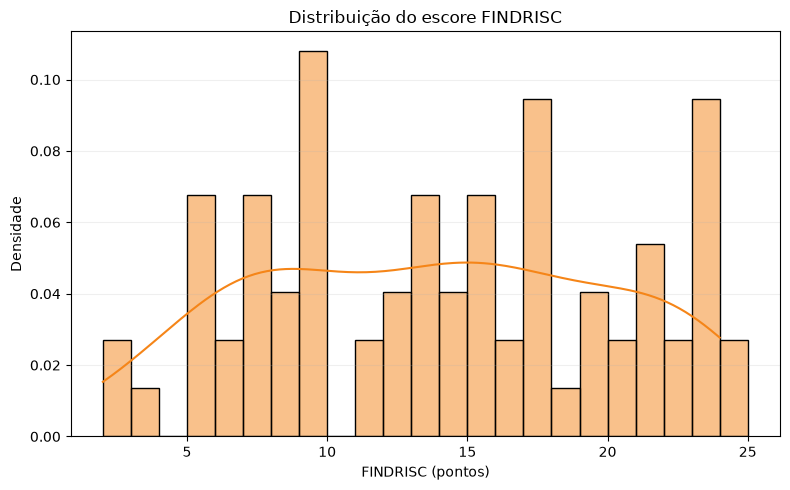

In [8]:
figure, _ = plot_findrisc_distribution(score)
save_figure(figure, FIGURES_DIR / 'findrisc_histogram_density.png')
plt.show()

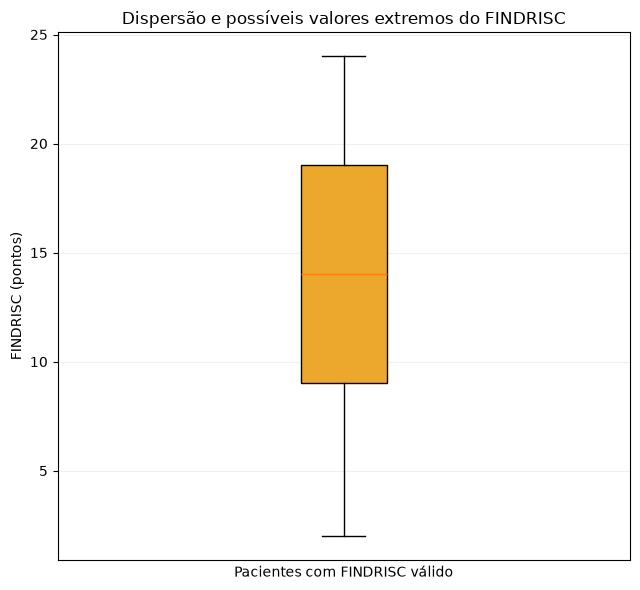

In [9]:
figure, _ = plot_findrisc_boxplot(score)
save_figure(figure, FIGURES_DIR / 'findrisc_boxplot.png')
plt.show()

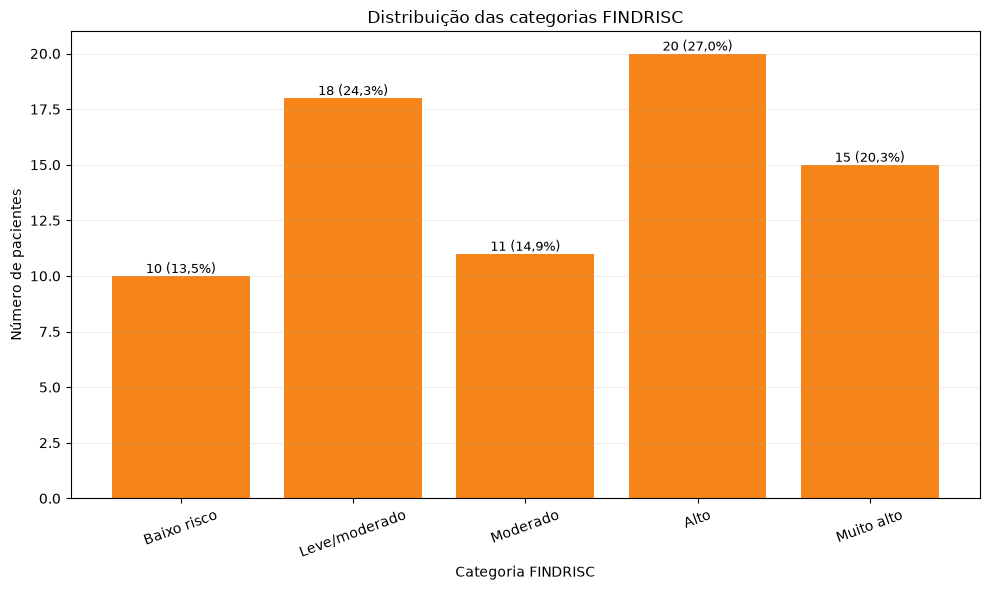

In [10]:
figure, _ = plot_findrisc_categories(df['findrisc_categoria'], order=CATEGORY_ORDER)
save_figure(figure, FIGURES_DIR / 'figure_2_findrisc_categories.png')
plt.show()

# 8. Conclusões deste notebook

In [11]:
print(
    'Distribuição: aproximadamente simétrica na amostra, com média 13,76, '
    'mediana 14, P25 9 e P75 19; o escore é discreto e limitado.'
)
print(
    f"Categoria mais frequente: {most_frequent['categoria']} — "
    f"{int(most_frequent['n'])}/{int(most_frequent['n_valido'])} "
    f"({most_frequent['percentual']:.2f}%)".replace('.', ',')
)
print(prevalence_text)
print(f'Extremos pelo critério de 1,5×IQR: {int(extreme_mask.sum())}')
print(f'Valores fora da faixa 0–26: {int(outside_instrument_range.sum())}')
print('Nenhum valor foi excluído.')

Distribuição: aproximadamente simétrica na amostra, com média 13,76, mediana 14, P25 9 e P75 19; o escore é discreto e limitado.
Categoria mais frequente: Alto — 20/74 (27,03%)
FINDRISC ≥15: 35/74 (47,30%; IC95% de Wilson: 36,34%–58,52%)
Extremos pelo critério de 1,5×IQR: 0
Valores fora da faixa 0–26: 0
Nenhum valor foi excluído.


# 9. Outputs gerados

As três figuras são exportadas em PNG a 300 DPI. O CSV bruto permanece inalterado.

In [12]:
figure_paths = [
    FIGURES_DIR / 'findrisc_histogram_density.png',
    FIGURES_DIR / 'findrisc_boxplot.png',
    FIGURES_DIR / 'figure_2_findrisc_categories.png',
]
assert all(path.exists() and path.stat().st_size > 0 for path in figure_paths)
raw_sha256 = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
assert raw_sha256 == 'a895b5340c856d2cd1772c8e115ed5efc20f409d3aef5ecba14da23d44da9bf4'
print('Figuras geradas:')
for path in figure_paths:
    print(f'- {path.relative_to(PROJECT_ROOT)}')
print('Integridade do arquivo bruto confirmada por SHA-256.')

Figuras geradas:
- outputs/figures/findrisc_histogram_density.png
- outputs/figures/findrisc_boxplot.png
- outputs/figures/figure_2_findrisc_categories.png
Integridade do arquivo bruto confirmada por SHA-256.
